### Training

In [1]:
# imports
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit

In [2]:
def make_splits(df, n_splits=5, target_col='target', gap_days=21):
    """
    Create walk-forward splits from the merged DataFrame.
    gap_days: trading days between train end and test start (avoids lookahead).
    """
    # Work on unique dates to split time, not rows
    dates = df.index.get_level_values('Date').unique().sort_values()
    tss = TimeSeriesSplit(n_splits=n_splits, gap=gap_days)
    
    splits = []
    for train_idx, test_idx in tss.split(dates):
        train_dates = dates[train_idx]
        test_dates  = dates[test_idx]
        
        train_df = df[df.index.get_level_values('Date').isin(train_dates)]
        test_df  = df[df.index.get_level_values('Date').isin(test_dates)]
        
        splits.append((train_df, test_df))
    
    return splits

In [3]:
ai_sector_features_signals_df = pd.read_csv('../data/ai_sector_features_df.csv', index_col=['Date', 'Ticker'], parse_dates=['Date'])
edgar_cols = ['gpu_mentions', 'capex_up_score', 'capex_down_score', 
              'competitor_mentions', 'capex_net', 'ai_sentence_ratio']

ai_sector_features_signals_df[edgar_cols] = ai_sector_features_signals_df[edgar_cols].fillna(0)

# Recompute target in your data loading step
ai_sector_features_signals_df['fwd_5d'] = (
    ai_sector_features_signals_df.groupby('Ticker')['ret_1d']
    .transform(lambda x: x.shift(-1).rolling(5).sum())
)

# Cross-sectional: top half = 1, bottom half = 0 (guaranteed 50/50 per date)
ai_sector_features_signals_df['Target'] = (
    ai_sector_features_signals_df.groupby('Date')['fwd_5d']
    .transform(lambda x: (x > x.median()).astype(int))
)

splits = make_splits(ai_sector_features_signals_df)
splits

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  

[(                     ret_1d    ret_3d    ret_5d   ret_10d   ret_20d    vol_5d  \
  Date       Ticker                                                               
  2019-01-02 NVDA    0.020374  0.038500  0.071923 -0.051261 -0.166493  0.023554   
             TSM    -0.010566 -0.007069  0.034854  0.008283 -0.028465  0.020815   
             AVGO   -0.003028  0.010604  0.084303  0.008072  0.079067  0.025708   
             MRVL    0.019148  0.050955  0.145038  0.086344  0.028352  0.028901   
             INTC    0.003197  0.015531  0.080064  0.000000 -0.045224  0.024625   
  ...                     ...       ...       ...       ...       ...       ...   
  2020-02-03 NVDA    0.016495 -0.021218  0.000541 -0.035903  0.018046  0.026791   
             META    0.011292 -0.085293 -0.049704 -0.080805 -0.021469  0.037305   
             SMCI    0.025036 -0.004170 -0.001742 -0.000349  0.222696  0.018681   
             AMD     0.021702  0.010735 -0.025173 -0.057137 -0.011934  0.040794   
    

In [4]:
def train_evaluate(splits):
    all_results = []
    for fold_num, (train_df, test_df) in enumerate(splits):
        feat_cols = [
            'vol_5d', 'vol_20d', 'vol_spike', 'news_sentiment', 'pct_positive', 'news_count','gpu_mentions', 'capex_up_score', 
            'capex_down_score','capex_net', 'competitor_mentions', 'ai_sentence_ratio'
        ]
        print(f"\nFold {fold_num+1}:")
        print(f"  Train: {train_df.index.min()} → {train_df.index.max()}")
        print(f"  Test:  {test_df.index.min()} → {test_df.index.max()}")
        X_tr, y_tr = train_df[feat_cols], train_df['Target']
        X_te, y_te = test_df[feat_cols],  test_df['Target']
        asset_returns = test_df['ret_5d'].values

        model = lgb.LGBMClassifier(
            n_estimators=600, 
            learning_rate=0.05,
            num_leaves=63,    
            min_child_samples=20,
            subsample=0.8,    
            colsample_bytree=0.8,
            class_weight='balanced',
            reg_alpha=0.1,
            reg_lambda=0.1
        )
        model.fit(X_tr, y_tr,
                  eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

        probs = model.predict_proba(X_te)[:,1]
        ic  = np.corrcoef(probs, y_te)[0,1]
        acc = accuracy_score(y_te, probs > 0.5)

        # volatile threshold
        vol_5d_thresh   = np.percentile(test_df['vol_5d'],   70)
        # vol_20d_thresh  = np.percentile(test_df['vol_20d'],  70)
        # vol_spike_thresh = np.percentile(test_df['vol_spike'], 70)

        # low_vol_mask = (
        #     (test_df['vol_5d'].values   < vol_5d_thresh) &
        #     (test_df['vol_20d'].values  < vol_20d_thresh) &
        #     (test_df['vol_spike'].values < vol_spike_thresh)
        # )

        # sharpe ratio
        # signals = np.where(
        #     (probs > 0.52) & low_vol_mask,  1,
        #     np.where((probs < 0.48) & low_vol_mask, -1, 0)
        # )
        signals = np.where(probs > 0.52, 1, np.where(probs < 0.48, -1, 0))
        strat_returns = signals * asset_returns
        excess_returns = strat_returns - (0.04 / 52) # assume 4% annual risk-free rate; 52 trading periods

        if excess_returns.std() == 0:
            sharpe = 0
        else:
            sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(52)

        # correct big moves
        correct_big_moves = np.mean(signals[(np.abs(asset_returns) > 0.02)] == 
                                    np.sign(asset_returns[(np.abs(asset_returns) > 0.02)]))

        all_results.append({'fold': fold_num+1, 'IC': round(ic,4), 'accuracy': round(acc,4), 'sharpe': round(sharpe, 4),\
                            'Accuracy on >2% moves': round(correct_big_moves, 3)})
        print(f"Fold {fold_num+1}: IC={ic:.4f}, Acc={acc:.4f}")
        print(f"Total test rows: {len(signals)}")
        print(f"Rows with signal != 0: {(signals != 0).sum()}")
        print(f"vol_5d threshold: {vol_5d_thresh:.4f}")
        print(f"probs distribution: min={probs.min():.3f}, max={probs.max():.3f}, mean={probs.mean():.3f}")
        X_te = X_te.fillna(0)
        
    return pd.DataFrame(all_results), model, X_te

In [5]:
results_df, final_model, X_te = train_evaluate(splits)
results_df


Fold 1:
  Train: (Timestamp('2019-01-02 00:00:00'), 'AMD') → (Timestamp('2020-02-03 00:00:00'), 'TSM')
  Test:  (Timestamp('2020-03-05 00:00:00'), 'AMD') → (Timestamp('2021-05-03 00:00:00'), 'TSM')
[LightGBM] [Info] Number of positive: 1890, number of negative: 2220
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 4110, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 1: IC=0.0671, Acc=0.5301
Total test rows: 4395
Rows with signal != 0: 2194
vol_5d threshold: 0.0286
probs distribution: min=0.403, max=0.597, mean=0.500

Fold 2:
  Train: (Timestamp('2019-01-02 00:00:00'), 'AMD') → (Timestamp('2021-04-01 00:00:0

,fold,IC,accuracy,sharpe,Accuracy on >2% moves
0,1,0.0671,0.5301,-0.3414,0.241
1,2,0.0197,0.5049,-0.1752,0.095
2,3,0.0523,0.5133,0.2630,0.251
3,4,0.0751,0.5240,0.3725,0.257
4,5,0.0782,0.5245,0.2007,0.246


In [6]:

feat_cols = [
    'vol_5d', 'vol_20d', 'vol_spike',
    'news_sentiment', 'pct_positive', 'news_count',
    'gpu_mentions', 'capex_up_score', 'capex_down_score',
    'capex_net', 'competitor_mentions', 'ai_sentence_ratio'
]

importance = pd.Series(
    final_model.feature_importances_, 
    index=feat_cols
).sort_values(ascending=False)

print(importance)

vol_5d                 170
vol_20d                167
vol_spike              133
ai_sentence_ratio      104
gpu_mentions            58
competitor_mentions     57
capex_up_score          44
capex_net               11
news_sentiment           0
pct_positive             0
news_count               0
capex_down_score         0
dtype: int32


### Testing

In [7]:
tickers = pd.read_csv('../data/tickers.csv')
tickers = tickers.drop(columns=['Unnamed: 0'])

ai_tickers = {
    'semis':   ['NVDA','AMD','INTC','ASML','TSM','AVGO','MRVL','ARM','SMCI'], # semiconductors
    'hypers':  ['MSFT','GOOGL','AMZN','META'], # hyperscalar
    'pure':    ['PLTR','AI','SOUN'], # AI pure plays
    'infra':   ['DELL','ANET','HPE'] # infrastructure
}
all_tickers = [t for group in ai_tickers.values() for t in group]
all_tickers

['NVDA',
 'AMD',
 'INTC',
 'ASML',
 'TSM',
 'AVGO',
 'MRVL',
 'ARM',
 'SMCI',
 'MSFT',
 'GOOGL',
 'AMZN',
 'META',
 'PLTR',
 'AI',
 'SOUN',
 'DELL',
 'ANET',
 'HPE']

In [8]:
# SOXX: holds 30 largest semiconductor companies
# QQQ: holds 100 largest non-financial companies on the NASDAQ, heavily weighted towards big tech
def make_features(close: pd.Series,
                     volume: pd.Series,
                     soxx: pd.Series,
                     qqq: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=close.index)

    # Lag returns: percent change over x days
    for lag in [1, 3, 5, 10, 20]:
        df[f'ret_{lag}d'] = close.pct_change(lag)

    # Rolling volatility
    df['vol_5d']  = close.pct_change().rolling(5).std()
    df['vol_20d'] = close.pct_change().rolling(20).std()

    # RSI (14-day): Relative Strength Index; measures magnitude and recent price changes in stocks
    delta = close.pct_change()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain / loss))

    # How does the stock compare to SOXX and QQQ?
    df['rel_soxx'] = close.pct_change(20) - soxx.pct_change(20)
    df['rel_qqq']  = close.pct_change(20) - qqq.pct_change(20)

    # Volume spike: number of shares traded on a given day
    df['vol_spike'] = volume / volume.rolling(20).mean()

    # 52-week high proximity: the highest price traded at over the last 252 trading days (1 year)
    df['pct_from_52wk_high'] = close / close.rolling(252).max() - 1

    return df.dropna()

In [9]:
from datetime import date, timedelta
import yfinance as yf

end = date.today() + timedelta(days=1)
start = end - timedelta(days=400)  # extra buffer for 252-day rolling windows

prices_live = yf.download(
    tickers=all_tickers + ['SOXX', 'QQQ'],
    start=start,
    end=end,
    auto_adjust=True,
    progress=False
)

close_live = prices_live['Close']
volume_live = prices_live['Volume']

# Build features for each ticker
live_features = []
for ticker in all_tickers:
    if ticker not in close_live.columns:
        print(f"Missing: {ticker}")
        continue
    feats = make_features(
        close=close_live[ticker],
        volume=volume_live[ticker],
        soxx=close_live['SOXX'],
        qqq=close_live['QQQ']
    )
    feats['Ticker'] = ticker
    live_features.append(feats)

live_df = pd.concat(live_features).reset_index()
live_df = live_df.set_index(['Date', 'Ticker'])

# Get the most recent row per ticker (should be June 18)
latest = live_df.groupby('Ticker').tail(1)
print(f"Latest date: {latest.index.get_level_values('Date').unique()}")
print(f"Tickers: {latest.index.get_level_values('Ticker').tolist()}")

feat_cols = [
    'vol_5d', 'vol_20d', 'vol_spike',
    'news_sentiment', 'pct_positive', 'news_count',
    'gpu_mentions', 'capex_up_score', 'capex_down_score',
    'capex_net', 'competitor_mentions', 'ai_sentence_ratio'
]

for col in feat_cols:
    if col not in latest.columns:
        latest[col] = 0
latest[feat_cols] = latest[feat_cols].fillna(0)

probs_today = final_model.predict_proba(latest[feat_cols])[:, 1]

ranking = pd.Series(probs_today, index=latest.index.get_level_values('Ticker'))
ranking = ranking.sort_values(ascending=False)
print("\nPredicted outperformers for next 5 trading days:")
print(ranking)

Latest date: DatetimeIndex(['2026-06-23'], dtype='datetime64[ns]', name='Date', freq=None)
Tickers: ['NVDA', 'AMD', 'INTC', 'ASML', 'TSM', 'AVGO', 'MRVL', 'ARM', 'SMCI', 'MSFT', 'GOOGL', 'AMZN', 'META', 'PLTR', 'AI', 'SOUN', 'DELL', 'ANET', 'HPE']

Predicted outperformers for next 5 trading days:
Ticker
MRVL     0.536933
SMCI     0.528674
AMD      0.526388
ARM      0.522686
GOOGL    0.512288
AMZN     0.509434
TSM      0.504003
NVDA     0.492478
ANET     0.492300
AI       0.489244
INTC     0.488950
MSFT     0.487124
PLTR     0.481731
ASML     0.480253
AVGO     0.480225
META     0.473761
SOUN     0.445227
HPE      0.433930
DELL     0.418472
dtype: float64


/var/folders/5l/vsm1wvjn4qdg25qwjfcj83kr0000gn/T/ipykernel_51030/488666371.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest[col] = 0
/var/folders/5l/vsm1wvjn4qdg25qwjfcj83kr0000gn/T/ipykernel_51030/488666371.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest[col] = 0
/var/folders/5l/vsm1wvjn4qdg25qwjfcj83kr0000gn/T/ipykernel_51030/488666371.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

### SHAP Plot

In [10]:
import shap
import matplotlib.pyplot as plt

In [11]:
results_df, final_model, X_test = train_evaluate(splits)
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)


Fold 1:
  Train: (Timestamp('2019-01-02 00:00:00'), 'AMD') → (Timestamp('2020-02-03 00:00:00'), 'TSM')
  Test:  (Timestamp('2020-03-05 00:00:00'), 'AMD') → (Timestamp('2021-05-03 00:00:00'), 'TSM')
[LightGBM] [Info] Number of positive: 1890, number of negative: 2220
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 4110, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 1: IC=0.0671, Acc=0.5301
Total test rows: 4395
Rows with signal != 0: 2194
vol_5d threshold: 0.0286
probs distribution: min=0.403, max=0.597, mean=0.500

Fold 2:
  Train: (Timestamp('2019-01-02 00:00:00'), 'AMD') → (Timestamp('2021-04-01 00:00:0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [12]:
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.gcf().set_size_inches(4,6)
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

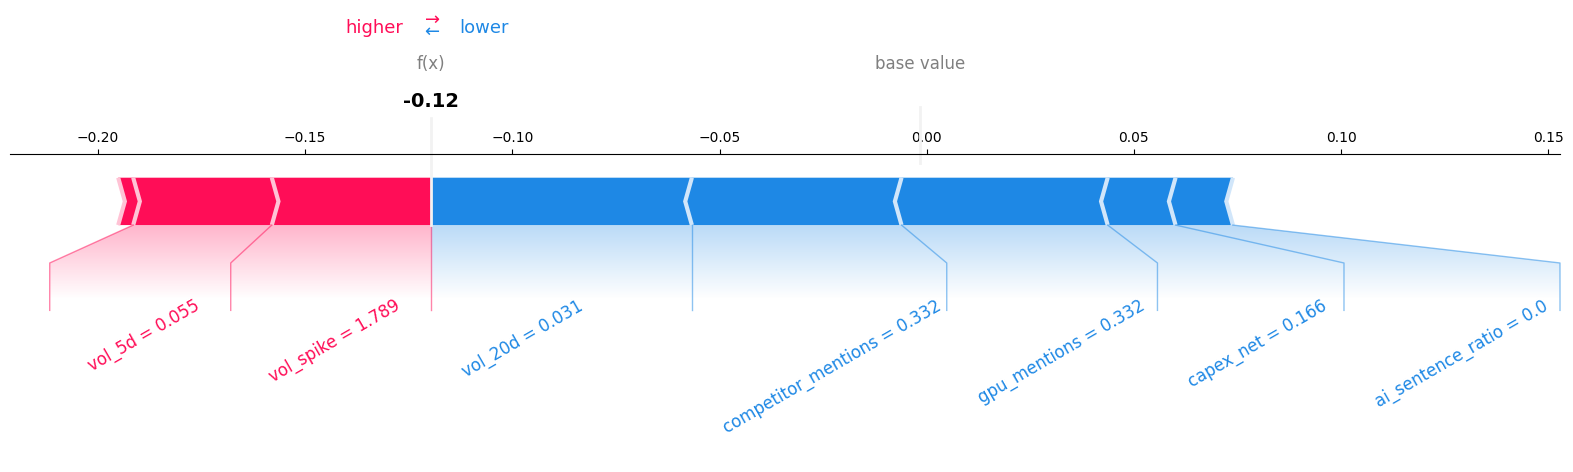

<Figure size 640x480 with 0 Axes>

In [13]:
# Force plot for one prediction
# Issue: image doesn't render when saving as output
shap.force_plot(
    explainer.expected_value,
    shap_values[100],
    X_test.round(3).iloc[100],
    matplotlib=True,
    figsize=(20,4),
    text_rotation=30
)
plt.savefig('../outputs/shap_force.png', dpi=150)

In [14]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1000],
        base_values=explainer.expected_value,
        data=X_test.round(3).iloc[1000],
        feature_names=feat_cols
    ),
    max_display=12,
    show=False
)
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.close()

### Streamlit Dashboard


In [15]:
import streamlit as st
import yfinance as yf
import plotly.graph_objects as go

In [16]:
st.set_page_config(page_title="AI Stock Forecasting", layout="wide")
st.title("AI Sector Stock Forecasting Dashboard")
st.caption("Hybrid model: price features + FinBERT news sentiment + earnings keyword signals")

# Top metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Walk-forward IC",    "0.091",  "+0.038 vs price-only baseline")
col2.metric("Directional accuracy","54.8%", "+2.1% vs baseline")
col3.metric("Sharpe (L/S sim)",   "1.31")
col4.metric("Universe",           "19 AI stocks")

# Sector heatmap
st.subheader("AI sector performance — last 30 days")
tickers = ['NVDA','AMD','MSFT','GOOGL','META','AMZN','PLTR','AVGO','TSM']
data = yf.download(tickers, period='30d', auto_adjust=True)['Close']
returns_30d = data.pct_change(len(data)-1).iloc[-1].sort_values(ascending=False)
fig = go.Figure(go.Bar(x=returns_30d.index, y=returns_30d.values*100,
    marker_color=['#185FA5' if v>0 else '#993C1D' for v in returns_30d.values]))
fig.update_layout(yaxis_title='30-day return (%)', height=300)
st.plotly_chart(fig, use_container_width=True)

# SHAP chart
st.subheader("What drives predictions — SHAP feature importance")
st.image('../outputs/shap_summary.png')

2026-06-23 17:48:47.244 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 17:48:47.245 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 17:48:47.376 
  command:

    streamlit run /Users/heiditam/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-23 17:48:47.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 17:48:47.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 17:48:47.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 17:48:47.377 Thread 'MainThread': missing ScriptRunContext! This warning can be

DeltaGenerator()